In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
from cycler import cycler


# Define high-contrast color palette
# 1. Deep Blue, 2. Brick Red, 3. Forest Green, 4. Muted Purple, 5. Safety Orange, 
# 6. Chestnut Brown, 7. Raspberry Pink, 8. Slate Gray, 9. Olive Gold, 10. Teal/Cyan

general_colors = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf' ]
light_colors = ['#0047AB',  '#FF0000',  '#00CC00',  '#9932CC',  '#FF8C00',  '#FF00FF',  '#FFD700',  '#00CED1',  '#FF4500',  '#7FFF00']

# General graph settings
plt.rcParams.update({
    # Font settings
    'font.family': 'sans-serif',          # Universal font family
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'], # Fallback fonts
    # 'font.family': 'serif',          # Cambiato da sans-serif a serif
    # 'font.serif': ['Computer Modern', 'Times New Roman', 'DejaVu Serif'], # Lista di font serif
    'mathtext.fontset': 'cm',        # Imposta i simboli matematici nello stile di LaTeX (Computer Modern
    # 'mathtext.fontset': 'stix',           # Makes LaTeX math symbols match the text font style
    
    # Color cycle settings
    'axes.prop_cycle': cycler(color=light_colors), # Sets the default color sequence for multiple lines
    
    # Size and resolution
    'font.size': 14,                      # General font size
    'axes.labelsize': 14,                 # Size of axis labels (x, y)
    'axes.titlesize': 16,                 # Size of the plot title
    'legend.fontsize': 12,                # Legend font size
    
    # Line and marker aesthetics
    'lines.linewidth': 2,                 # Line width
    'lines.markersize': 5,                # Marker size
    'figure.figsize': (10, 6),            # Default figure size
    
    # Grid settings
    'axes.grid': True,                    # Enable grid by default
    'grid.alpha': 0.4,                    # Make grid slightly transparent
    'grid.linestyle': '--',               # Dashed grid style
    'errorbar.capsize': False                 # Add caps to error bars
})

# Exercise 03



## Exercise 03.1

### Assignment

Black-Scholes theory assumes that the time evolution of the asset price is stochastic and exhibits geometric Brownian motion (GBM) with constant risk-free interest rate $r$ and volatility $\sigma$.

Black-Scholes analytic solution for the price at time t<T:
- European Call-option price:
$$ C\left[ S(t),t \right] = S(t) N(d_1) -K e^{-r(T-t)} N(d_2) $$
- European Put-option price:
$$ P\left[ S(t),t \right] = S(t) \left[ N(d_1)-1\right] -K e^{-r(T-t)} \left[ N(d_2)-1\right]$$

where 
$$d_1 = \frac{1}{\sigma\sqrt{T-t}}\left[ \ln \left( \frac{S(t)}{K} \right) + \left( r+\frac{\sigma^2}{2} (T-t) \right)\right]$$

where $d_2 = d_1 - \sigma\sqrt{T-t}$, and where
$$ N(x) = \int_{-\infty}^{x} dz \, e^{-\frac{z^2}{2}} = \frac{1}{2} \left[ 1+ {\rm erf} \left( \frac{x}{\sqrt{2}}\right) \right]$$
is the cumulative of Gaussian $\sim \mathcal{N}(\mu=0,\sigma^2=1)$,
and where
$${\rm erf}(x) = \frac{2}{\sqrt{\pi}}\int_{0}^{x} dz \, e^{-z^2}$$

By using the following parameters: 
- asset price at $t=0$: $S(0)=100$
- delivery time: $T=1$
- strike price: $K=100$
- risk-free interest rate: $r=0.1$
- volatility: $\sigma=0.25$

compute at time $t=0$ **via Monte Carlo** the European call-option price, $C[S(0),0]$, and put-option price, $P[S(0),0]$:

1. By sampling **directly** the final asset price ${S(T)}$ for a $GBM(r, \sigma^2)$
2. By sampling the discretized ${GBM(r, \sigma^2)}$ path of the asset price
dividing $[0,T]$ in $10^2$ time intervals: $S(0)$, $S(t_1)$, $S(t_2)$, ... up to $S(t_{100}=T=1)$

Make four pictures for the estimation of the European call-option prices, ${C[S(0),0]}$ (direct and discretized), and put-option prices, ${P[S(0),0]}$ (direct and discretized), with their uncertainties with a large number of asset prices at time $t=T$, say $M\ge 10^4$, as a function of the number of blocks, $N$. As usual, in computing statistical uncertainties, use data blocking.

### Solution

The exercise requires the computation of the price of a European call option $C[S(0),0]$ and a put option $P[S(0),0]$ at time $t=0$ using Monte Carlo methods. Specifically, both direct and discrete (step-by-step) sampling approaches must be implemented, using the parameters provided.

In [2]:
# Valori teorici esatti calcolati con Black-Scholes
call_teorico = 14.975790778311286
put_teorico = 5.4595325819072364

# Funzione di supporto per caricare i dati
def load_data(filename):
    data = np.loadtxt(filename)
    return data[:, 0], data[:, 1], data[:, 2]

1. Direct Sampling

The final price $S(T)$ is sampled directly, assuming the asset price follows a Geometric Brownian Motion (GBM) characterized by the parameters $r$ and $\sigma^2$.

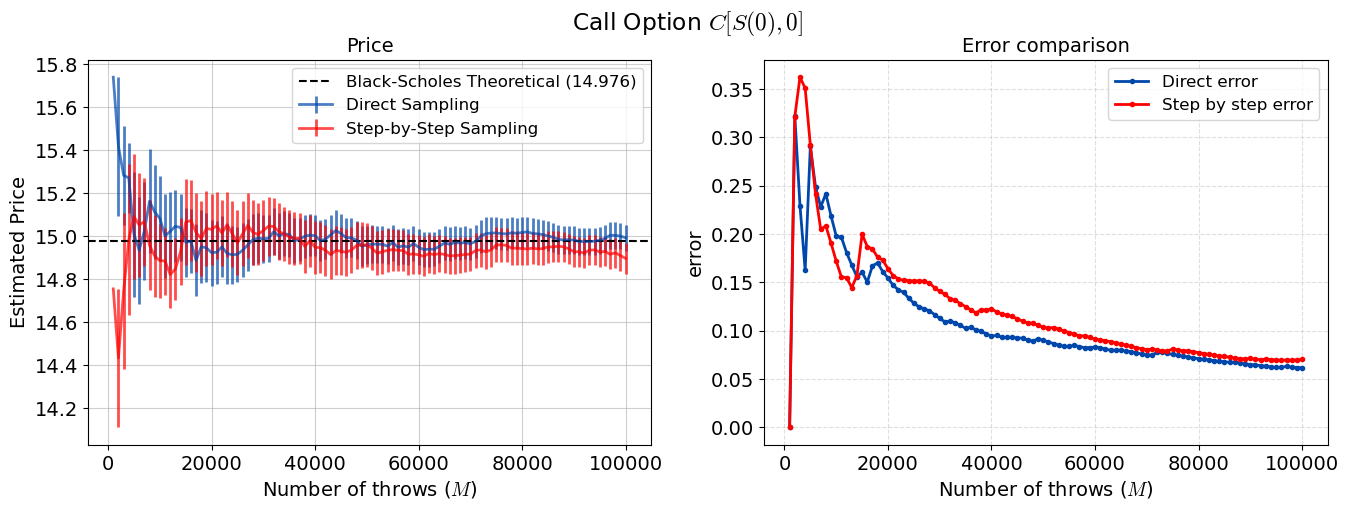

In [3]:
# Load the datasets
x_dir, y_dir, err_dir = load_data("call_direct.dat")
x_sbs, y_sbs, err_sbs = load_data("call_sbs.dat")


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16,5))


# Plot the Direct Monte Carlo results
axes[0].errorbar(x_dir, y_dir, yerr=err_dir, label='Direct Sampling', 
             alpha=0.7)

# Plot the Step-by-Step results (overlay)
axes[0].errorbar(x_sbs, y_sbs, yerr=err_sbs, label='Step-by-Step Sampling', 
              alpha=0.7)

# Add the theoretical Black-Scholes reference line
axes[0].axhline(y=call_teorico, color='black', linestyle='--', linewidth=1.5, 
            label=f'Black-Scholes Theoretical ({call_teorico:.3f})')

# Graph formatting
plt.suptitle(r'Call Option $C [S(0),0]$')
axes[0].set_title(r'Price', fontsize=14)
axes[0].set_xlabel(r'Number of throws ($M$)')
axes[0].set_ylabel(r'Estimated Price')
axes[0].grid(True, linestyle='-', alpha=0.6)
axes[0].legend(loc='best')

# Display the plot
# plt.tight_layout()
# plt.show()

# Errors
axes[1].plot(x_dir, err_dir, marker='o', markersize=3,
             label='Direct error')

# Importance Sampling plot
axes[1].plot(x_sbs, err_sbs, marker='o', markersize=3,
             label=r'Step by step error')

# Titles and Labels
axes[1].set_title(r'Error comparison', fontsize=14)
axes[1].set_xlabel(r'Number of throws ($M$)')
axes[1].set_ylabel(r'error')
axes[1].legend(loc='best')

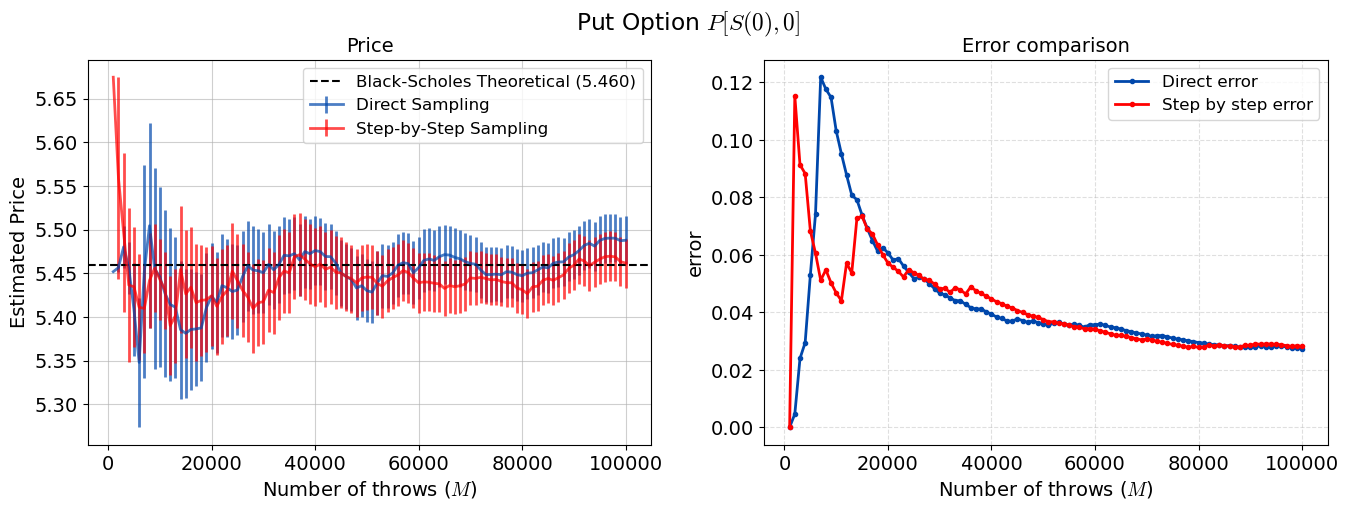

In [4]:
# Load the datasets
x_dir, y_dir, err_dir = load_data("put_direct.dat")
x_sbs, y_sbs, err_sbs = load_data("put_sbs.dat")


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16,5))


# Plot the Direct Monte Carlo results
axes[0].errorbar(x_dir, y_dir, yerr=err_dir, label='Direct Sampling', 
             alpha=0.7)

# Plot the Step-by-Step results (overlay)
axes[0].errorbar(x_sbs, y_sbs, yerr=err_sbs, label='Step-by-Step Sampling', 
              alpha=0.7)

# Add the theoretical Black-Scholes reference line
axes[0].axhline(y=put_teorico, color='black', linestyle='--', linewidth=1.5, 
            label=f'Black-Scholes Theoretical ({put_teorico:.3f})')

# Graph formatting
plt.suptitle(r'Put Option $P [S(0),0]$')
axes[0].set_title(r'Price', fontsize=14)
axes[0].set_xlabel(r'Number of throws ($M$)')
axes[0].set_ylabel(r'Estimated Price')
axes[0].grid(True, linestyle='-', alpha=0.6)
axes[0].legend(loc='best')

# Errors
axes[1].plot(x_dir, err_dir, marker='o', markersize=3,
             label='Direct error')

# Importance Sampling plot
axes[1].plot(x_sbs, err_sbs, marker='o', markersize=3,
             label=r'Step by step error')

# Titles and Labels
axes[1].set_title(r'Error comparison', fontsize=14)
axes[1].set_xlabel(r'Number of throws ($M$)')
axes[1].set_ylabel(r'error')
axes[1].legend(loc='best')

The plots show that both the direct method and the step by step one are consistent with the Black-Scholes theory. It is observed that in both the call and the put options, the error is quite similar between the two methods: it has a peak after few throws, and then it settles back to a stable value. In the end, the relative error on the price is less than 1%.